### Group Members:

- Daria Stetsenko, 23-740-806
- Name, matriculation number
- Name, matriculation number

# Assignment 4: Auto-Encoder (AE), Out-of-Distribution (OOD) Detection and Open-Set Recognition (OSR)

In this assignment, we show that it is possible to perform a (non-linear) dimensionality reduction by learning from unlabeled data using a convolutional auto-encoder network.
The task is to reduce an image of the handwritten digits of MNIST into a deep feature representation, without making use of their labels, and reconstruct the sample from that representation.

For this purpose, we implement a convolutional auto-encoder that is composed of two sub-networks.
An *encoder* network composed of several strided convolution layers, which finally performs an embedding in a $K=10$-dimensional deep feature representation.
The *decoder* uses this deep feature representation to reconstruct an image in the original size of $28\times28$ pixels by applying a series of fractionally-strided transposed convolutional layers.

After training such a network, we show that this has learned well the distribution of the known classes, which are represented by the MNIST test sample.
On the other hand, we show that this network has limited representation capabilities for *near OOD* samples coming from the related EMNIST letters dataset.
Also, we use *far OOD* samples coming from the Fashion-MNIST dataset to show that such samples are not represented in the embedding space of our auto-encoder.

For both of these types of OOD samples, we show that our auto-encoder network can be used to detect out-of-distribution data in the test set, and perform open-set recognition.
Particularly, we make use of the reconstruction error of our auto-encoder to distinguish known and OOD samples.
Additionally, we compute centroids of embedding vectors for all known classes, and use distances to such classes for classification.

## Section 1: Theoretical Questions

In this section we first investigate core questions regarding auto-encoder networks, for example, how to achieve a vector representation for the deep features. Afterward, we discuss some characteristics of approaches to open-set recognition.

### Task 1.1: PCA vs. Two-Layer Autoencoder

Principal Component Analysis (PCA) and two-layer AutoEncoders (AE) are two different ways for projecting a vector input vector $\vec x \in \mathbb R^D$ into a vector representation $\vec \varphi \in \mathbb R^K$ with $K \ll D$.
In both cases, a projection matrix $\mathbf W$ is learned to perform this task.
For PCA, this projection is applied as $\vec\varphi = \mathbf W(\vec x - \tilde x)$ where $\tilde x$ is the mean of the samples over the training set.
A two-layer autoencoder is composed of an encoder with one fully-connected layer $\mathbf W^{(1)} \in \mathbb R^{K\times(D+1)}$, and a decoder containing one fully-connected layer $\mathbf W^{(2)} \in \mathbb R^{(K+1)\times D}$, each including a bias neuron.

**Question**: What is the difference between PCA and the two-layer autoencoder with respect to the embedding matrix $\mathbf W$, and the learning procedure? Is there any theoretical difference how the bias is handled between the two methods? 

**Answers**:

- **Embedding matrix $\mathbf W$**: In PCA there is a *single* projection matrix whose rows are constrained to be orthonormal — they are the top-$K$ eigenvectors of the data covariance matrix. The same matrix is used both to project into the latent space and (via $\mathbf W^\mathsf{T}$) to reconstruct the input, so encoder and decoder weights are *tied*. In the two-layer autoencoder there are *two independent* matrices $\mathbf W^{(1)}$ (encoder) and $\mathbf W^{(2)}$ (decoder); they are not tied and have no orthogonality constraint.
- **Learning procedure**: PCA has a *closed-form* solution obtained by an eigen- (or SVD-) decomposition of the centered data; it is deterministic and globally optimal w.r.t. the squared reconstruction error under the orthogonality constraint. The autoencoder is trained *iteratively* by gradient descent on the reconstruction loss; the optimization is non-convex (because $\mathbf W^{(1)}$ and $\mathbf W^{(2)}$ are multiplied), depends on initialization, and only converges to a local optimum. With linear activations and tied weights an AE spans the same subspace as PCA but does not necessarily recover the orthonormal principal axes.
- **Bias**: PCA does *not* learn a bias; it removes the mean $\tilde x$ as an explicit pre-processing step, so centering is hard-coded. The autoencoder *learns* its biases jointly with the weights: the encoder bias absorbs (a transformed version of) the input mean, and the decoder bias adds back the output mean, but neither has to coincide with the data mean — they are free parameters that minimize the reconstruction error. Conceptually the bias plays the same centering role, but in PCA it is fixed analytically while in the AE it is learned.

### Task 1.2: Options for One-Dimensional Feature Vectors in Latent Space

In a convolutional autoencoder, the encoder typically employs a series of convolutional layers, which provides feature maps $\mathcal A\in\mathbb R^{Q\times K\times M}$. 
The embedding vector, however, is required to be a vector with a desired number of elements.

**Question**: What are the different approaches to obtaining a one-dimensional feature vector in the latent space of autoencoders?

**Answers**:

1. **Flatten + fully-connected layer**: Reshape the feature maps $\mathcal A \in \mathbb R^{Q\times K\times M}$ into a single vector of length $Q\cdot K\cdot M$ and feed it through a fully-connected layer mapping to the desired latent dimension. This is the approach used in this assignment. It is flexible but introduces many parameters and ties the encoder to a fixed input resolution.
2. **Global pooling (average / max)**: Apply global average pooling or global max pooling across the spatial dimensions, producing one value per channel and hence a vector of length $Q$. Parameter-free and invariant to spatial size, but discards spatial information.
3. **1×1 convolutions to a target channel count followed by global pooling**: First reduce the number of channels with a 1×1 convolution to exactly $K_{\text{latent}}$ channels, then apply global pooling.
4. **Strided / valid convolutions until spatial size is 1×1**: Continue applying strided (or valid-padded) convolutions until the spatial dimensions collapse to $1\times1$, leaving a feature map of shape $Q\times 1\times 1$ that is squeezed into a vector of length $Q$.
5. **Adaptive pooling**: Use an adaptive average/max pooling layer that produces a fixed spatial output (e.g. $1\times1$) regardless of input size, then flatten.

### Task 1.3: Two-Step Approach for OSR - Pros and Cons

In open-set recognition, two-stage approaches first perform a binary classification of a sample to be *known* or *unknown*, and then classify all *known* samples as their respective class.

**Question**: What are the advantages and disadvantages of employing such a two-step approach for Open-Set Recognition?

**Answers**:

**Advantages**
- *Modularity*: the two stages can be designed, trained and evaluated independently. Any state-of-the-art OOD detector can be combined with any closed-set classifier.
- *Specialization*: each model is optimized for a single task; the closed-set classifier does not have to "leave room" for unknowns, and the OOD detector can use specialized features (reconstruction error, density estimates, energy scores, ...).
- *Reuse of existing models*: a standard pre-trained classifier can be combined with an unsupervised OOD detector without retraining.
- *Interpretability*: it is clear which stage produced an error — failure to reject an unknown vs. misclassification within the knowns.

**Disadvantages**
- *Error propagation*: stage-1 errors are unrecoverable. A known sample wrongly rejected can never be classified, and an unknown wrongly accepted is forced into a known class.
- *No joint optimization*: the two stages are trained with separate objectives, so the open-set objective is not directly optimized; the system is generally suboptimal compared to an end-to-end approach.
- *Threshold tuning*: a separate threshold/calibration is required and is often sensitive to distribution shift between training and test time.
- *Decoupled features*: the features used for OOD detection and for classification may differ, leading to inconsistent decisions and additional computational cost (two forward passes / two networks).
- *Class-imbalance issues*: stage 1 sees a binary problem in which the unknown class is very heterogeneous and unbounded, which makes the binary boundary hard to define.

### Task 1.4: Entropic Open-Set (EOS) Loss Bias

The Entropic Open-Set (EOS) loss aka. the Softmax Adaptation requires having no bias in the final fully-connected layer that transforms the deep features $\vec\varphi$ to the logits: $\vec z = W^{(L)} \vec\varphi$.

**Question**: Why is it theoretically impossible to introduce a bias for the Entropic Open-Set (EOS) loss?

**Answer**:

The EOS loss requires that for every *negative* (unknown) sample the softmax output is the uniform distribution over the $C$ known classes, i.e. all logits are equal: $z_1 = z_2 = \ldots = z_C$. The natural way for the network to achieve this for *any* unknown input is to drive its deep feature $\vec\varphi$ to the zero vector, because then $\vec z = W^{(L)}\vec\varphi = \vec 0$, all logits equal $0$ and the softmax is uniform — which gives maximum entropy and minimizes the EOS loss.

If a bias term $\vec b$ is added, the logits at $\vec\varphi = \vec 0$ become $\vec z = \vec b$, which is in general *not* a constant vector. Hence the softmax is no longer uniform and the network can no longer satisfy the EOS objective by collapsing the features to the origin. Equivalently, the only way to make all logits equal *for every* negative sample regardless of its features is to require that every row of $W^{(L)}$ produces the same value; this is only possible (without constraining the weights) when the features can be pushed to a common point *and* there is no additive offset that breaks the symmetry. The bias breaks this symmetry, so it is incompatible with the EOS construction.

### Task 1.5: Selection of Negative Samples

EOS loss requires *negative* samples for training.

**Question**: Given a specific set of known classes, how should negative samples be selected? Can random noise be used as negatives?

**Answer**:

Negative samples should come from a distribution that is *similar to but disjoint from* the known classes — i.e. they should look like plausible inputs to the network (same modality, similar low-level statistics, similar domain) but must not belong to any of the known categories. For example, if the known classes are MNIST digits, suitable negatives are EMNIST letters or other handwritten symbols, since they share stroke and image statistics with digits but represent different semantic classes. The intuition is that the network must learn to produce low-confidence (uniform) predictions on inputs that lie *close to the decision boundary* of the known classes, since these are the inputs that would otherwise be confidently misclassified.

The negatives must also be *diverse* and ideally cover the regions of input space where unknowns may actually appear at test time (broad coverage of "near-OOD"), and they must be guaranteed to be disjoint from the known classes — otherwise the network is taught to assign uniform probability to true positives, which destroys closed-set accuracy.

**Random noise as negatives**: this is generally a poor choice. Pure random noise lies in a region of the input space that is statistically very different from natural images, so its convolutional features are far from the manifold of the known classes. The network can trivially separate noise from the knowns (e.g. via low-level statistics) without ever learning to lower its confidence on the kind of inputs real OOD samples produce. As a result, training with noise as negatives typically does not transfer to realistic OOD detection. Noise can serve as a weak auxiliary signal but should not replace semantically meaningful negatives.

### Task 1.6: Training with Negative Samples for Different OOD Detection Approaches

As mentioned above, we will make use of two methods for performing Out-of-Distribution (OOD) detection.
One is based on thresholding reconstruction error values, and one is based on distances in deep feature space.
More details on these two methods can be found at later sections in this notebook.

Theoretically, we could add the training samples of our unknown datasets (EMNIST letters, FashionMNIST) to our original training data (MNIST), and use all of these to train our autoencoder network.

**Question**: What do you expect: Is it advisable to train with additional samples when using autoencoders for OOD detection? Is there a difference between the two methods for OOD, i.e., thresholding reconstruction error or thresholding distances to class centroids in the deep feature space?

**Answer**:

In general it is **not advisable** to simply add the unknown samples to the autoencoder's training set, and the two OOD methods are affected differently.

- **Reconstruction-error method**: this approach relies on the fact that the autoencoder reconstructs *only* the known data well, so the reconstruction error is small for known samples and large for unknown ones. If the unknowns are added to the training set, the autoencoder learns to reconstruct them too, the reconstruction error on those samples drops, and the gap between known and unknown errors shrinks or disappears. The OOD signal is *destroyed*. For the reconstruction-based detector, adding unknown samples is harmful.
- **Centroid-distance method**: this method uses class centroids of the *known* classes in feature space and considers a sample OOD if it is far from every centroid. Since the autoencoder is unsupervised, naively adding unlabeled unknown samples does not provide a clear benefit: the encoder will simply learn an embedding that also represents the unknowns compactly, possibly placing them close to existing centroids and thereby hurting OOD detection. To benefit from negatives in this setting one would need an additional objective (e.g. EOS-like or contrastive) that explicitly *pushes unknown samples away* from the known centroids; with such an objective additional negatives can help. Without an explicit "push-away" loss, the centroid method suffers from the same problem as the reconstruction method, just usually to a smaller degree because the bottleneck still has to encode the extra variability.

In short: a vanilla autoencoder learns to represent whatever it is trained on, so feeding it unknowns undermines both detectors — strongly for the reconstruction-error method and somewhat less, but still negatively, for the centroid-distance method, unless the loss is modified to actively separate unknowns from knowns.

## Section 2: Coding

**<font color='red' size='5'>This section has to be submitted by 11:59 p.m. on Wednesday, May 13, to be graded.</font>**

The coding part is threefold.
First, we define everything that is required to train and evaluate our autoencoder network.
This includes the data sets used for training, validation and testing, as well as the datasets that serve as unknown samples for the OOD detection.

Afterward we define our convolutional autoencoder by defining an `Encoder` module and a `Decoder` module, which we combine to an auto-encoder.
We instantiate the auto-encoder and all other variables needed for training, and implement the training and validation loop.
Subsequently, we train our auto-encoder on our training dataset.

Finally, we use two different techniques for out-of-distribution detection using our trained autoencoder network.
First, we use the reconstruction error on our known and unknown datasets to distinguish between known and unknown samples.
Then, we use distances in deep feature space to perform the same task.

In [2]:
# import required packages
import torch                                   # core PyTorch library for tensors and autograd
import torchvision                             # datasets and image transforms
from torch.utils.data import DataLoader        # utility for iterating over datasets in batches
from matplotlib import pyplot                  # used for plotting images, curves and histograms
from sklearn.metrics import ConfusionMatrixDisplay   # used later for the confusion matrix plot

# Device configuration: pick GPU if one is available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print('Using GPU')
else:
    print('Using CPU. Warning: This will be slow!')

Using GPU


### Task 2.1: Datasets and Data Loaders

We will make use of `torchvision.datasets.EMNIST` dataset and `torchvision.datasets.FashionMNIST` dataset.
EMNIST has two splits, `mnist` and `letters`, with 10 labels of digit images and 26 labels of letter images respectively. 
FashionMNIST has 10 labels of merchandise images.
However, for the training of the Auto-Encoder (AE) we do not make use of the labels of the dataset, but we only utilize the images.
For testing purposes, we assign label `-1` to all unknown samples -- note that this is different from the theoretical part in the lecture, where we assign label `0` as unknown.

These datasets can be split into train sets and test sets by the default implementation.
We will use solely the MNIST split for training and validation of the AE network.
To evaluate this network for out-of-distribution detection, we will use the test sets from EMNIST letters and FashionMNIST respectively.

1. Create the `train_dataset` for the EMNIST `mnist` split.
2. Create test datasets for all datasets. For the test data loaders set `shuffle=True` for the sampling of images to be simpler, even though normally we would not shuffle the test set.
3. Create dataloaders for all datasets.

In [3]:
# Hyperparameters
batch_size = 128

# transform for FashionMNIST dataset: converts PIL image to a float tensor in [0,1]
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

# transform for EMNIST dataset
def rotate_image(image):
    """Transpose the last two axes of a tensor image to correct EMNIST orientation."""
    # Correct orientation of images
    return image.transpose(2, 1)
emnist_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    rotate_image,
])

# training set of mnist digits
train_dataset = torchvision.datasets.EMNIST(root='./data', split='mnist', train=True, download=True, transform=emnist_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# test dataset of mnist digits
test_dataset = torchvision.datasets.EMNIST(root='./data', split='mnist', train=False, download=True, transform=emnist_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# Create dataset and dataloader for EMNIST letters
emnist_letters_dataset = torchvision.datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=emnist_transform)
# Assign label to all EMNIST letter samples
emnist_letters_dataset.targets = torch.full_like(emnist_letters_dataset.targets, -1)

emnist_letters_loader = DataLoader(emnist_letters_dataset, batch_size=batch_size, shuffle=True)


# Create dataset and dataloader for FashionMNIST
fashion_mnist_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
# Assign -1 label to all FashionMNIST samples
fashion_mnist_dataset.targets = torch.full_like(fashion_mnist_dataset.targets, -1)
fashion_mnist_loader = DataLoader(fashion_mnist_dataset, batch_size=batch_size, shuffle=True)

# print the number of samples in each dataset for a sanity check
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of EMNIST letters samples: {len(emnist_letters_dataset)}")
print(f"Number of FashionMNIST samples: {len(fashion_mnist_dataset)}")


100%|██████████| 562M/562M [00:04<00:00, 132MB/s]  
100%|██████████| 26.4M/26.4M [00:00<00:00, 46.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.07MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 16.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.2MB/s]

Number of training samples: 60000
Number of test samples: 10000
Number of EMNIST letters samples: 20800
Number of FashionMNIST samples: 10000


We look at some images to get an idea of the data we are working with.
Notably, the letters are much more similar to the training data than the FashionMNIST data, therefore we call the letters near-OOD while the FashionMNIST data is far-OOD.

Note: We only look at the test sets now, to make sure that they are implemented correctly.

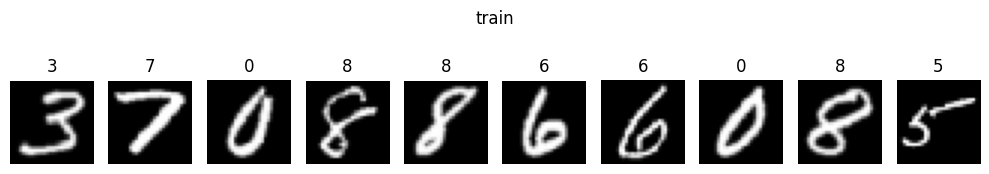

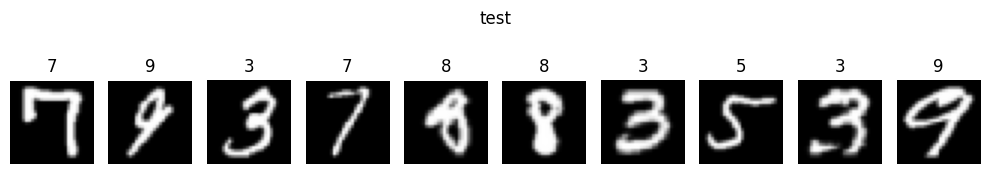

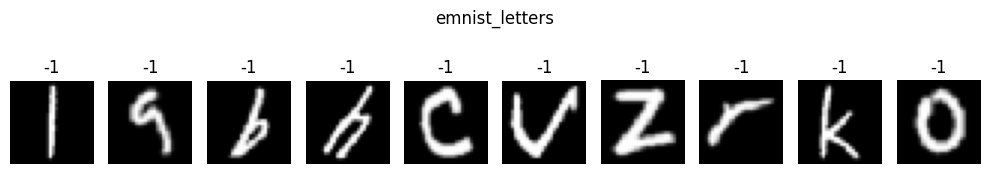

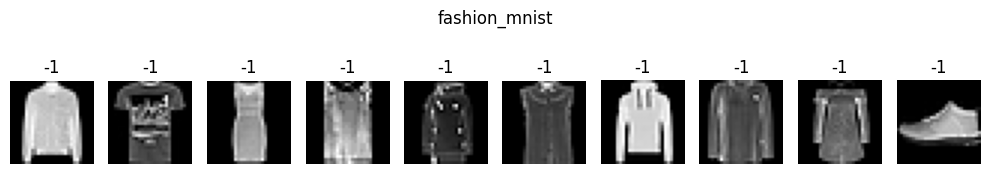

In [4]:
# look at some images from each dataset
def show_images(data_loader, title, nr_images = 10):
    """Plot a row of sample images from the first batch of a data loader."""
    # sample images from the dataset by grabbing a single batch
    images, labels = next(iter(data_loader))
    # create a figure with one subplot per image
    fig, axs = pyplot.subplots(1, nr_images, figsize=(nr_images, 2))
    fig.suptitle(title)
    # iterate and display each image with its label as the subplot title
    for i in range(nr_images):
        axs[i].imshow(images[i][0], cmap='gray')
        axs[i].set_title(labels[i].item())
        axs[i].axis('off')
    fig.tight_layout()
    pyplot.show()

# mapping from a human-readable name to the corresponding loader
datasets = {
    'train': train_loader,
    'test': test_loader,
    'emnist_letters': emnist_letters_loader,
    'fashion_mnist': fashion_mnist_loader
}
# visualize a few samples from every dataset
for name, loader in datasets.items():
    show_images(loader, name)

### Auto-Encoder Network

The auto-encoder network is composed of two parts: the encoder that transforms the input image to a deep feature representation; and the decoder that produces an image from such a deep feature.

For the encoder $\mathcal E$, we will use a convolutional network and perform down-sampling via striding.
After each convolution, we apply the ReLU activation.
The output of the encoder is a $K=10$ dimensional deep feature representation.
The complete encoder network topology can be found below in Topology 1(a).

The decoder $\mathcal D$ performs the inverse operations of the encoder.
A fully-connected layer is used to increase the number of samples to the same size as the output of the flattening of the encoder.
Then, the flattening needs to be undone by reshaping the vector into the correct dimensionality, followed by a ReLU activation.
A fractionally-strided convolutional layer increases the intermediate representation by a factor of 2.
Note that the fractionally-strided convolution is implemented in `torch.nn.ConvTranspose2d`, and the `stride` parameter should have the same value as for the encoder.
Additionally, the `torch.nn.ConvTranspose2d` has a parameter `output_padding` which needs to be adapted to reach the correct output shape (see Test 2).
After this layer, we perform another ReLU activation and another fractionally-strided convolution to arrive at the original input dimension.
The complete decoder network topology can be found below in Topology 1(b).

Finally, we combine the two sub-networks into one auto-encoder network.
While there exist several possibilities for doing this, we will implement a third `torch.nn.Module` that contains an instance of the encoder and an instance of the decoder.

Topology 1: Network configurations of the (a) encoder and (b) decoder networks

(a) Encoder Network

*   2D convolutional layer with $Q_1$ channels, kernel size $5\times5$, **stride 2** and padding 2
*   activation function ReLU
*   2D convolutional layer with $Q_2$ channels, kernel size $5\times5$, **stride 2** and padding 2
*   flatten layer to convert the convolution output into a vector
*   activation function ReLU
*   fully-connected layer with the correct number of inputs and $K$ outputs

(b) Decoder Network

*   fully-connected layer with $K$ inputs and the correct number of outputs
*   activation function ReLU
*   reshaping to convert the vector into a convolution input
*   2D **fractionally-strided convolutional** layer with $Q_2$ channels, kernel size $5\times5$, stride 2 and padding 2
*   activation function ReLU
*   2D **fractionally-strided convolutional** layer with $Q_1$ channels, kernel size $5\times5$, stride 2 and padding 2

### Task 2.2: Encoder Network
Implement the encoder network for given parameters $Q_1$, $Q_2$, and $K$ as given in Topology 1(a).
Implement a network class that derives from `torch.nn.Module` and implement the `__init__` and the `forward` methods.

In [5]:
class Encoder(torch.nn.Module):
    """Encoder sub-network of the convolutional auto-encoder.

    Constructor args:
        Q1, Q2: the number of convolutional channels for layer 1 and 2
        K: The dimensionality of the embedding vector
    """
    def __init__(self, Q1, Q2, K):
        # call base class constructor
        super(Encoder,self).__init__()
        # convolutional define layers
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=Q1, kernel_size=5, stride=2, padding=2)
        self.conv2 = torch.nn.Conv2d(in_channels=Q1, out_channels=Q2, kernel_size=5, stride=2, padding=2)
        # define fully-connected layers
        self.flatten = torch.nn.Flatten()
        # activation functions will be re-used for the different stages
        self.act = torch.nn.ReLU()
        # After two stride-2 convolutions on a 28x28 image (padding 2, kernel 5),
        # the spatial size becomes 7x7
        self.fc = torch.nn.Linear(Q2 * 7 * 7, K)

    def forward(self, x):
        """Run a forward pass producing the deep feature representation.

        Args:
        x: An input batch of size Bx1xHxW where B is the batch size and H=W=28 is the input image dimension

        Returns:
        The embedding batch of dimension BxK
        """
        # get the deep feature representation
        a = self.act(self.conv1(x))
        a = self.conv2(a)
        a = self.flatten(a)
        a = self.act(a)
        deep_feature = self.fc(a)
        return deep_feature


### Task 2.3: Decoder Network

Implement the decoder network for given parameters $Q_1$, $Q_2$, and $K$ as given in Topology 1(b).
Implement a network class that derives from `torch.nn.Module` and implement the `__init__` and the `forward` methods.
The output of the decoder network is supposed to have values in the range $[0,1]$, similar to the input values.
We need to make sure that only these values can be achieved.
Think of possible ways of doing that, and apply the way that seems most reasonable.

In [6]:
class Decoder(torch.nn.Module):
    """Decoder sub-network of the convolutional auto-encoder.

    Constructor args:
        Q1, Q2: the number of convolutional channels for layer 1 and 2 of the encoder network
        K: The dimensionality of the embedding vector
    """
    def __init__(self, Q1, Q2, K):
        # call base class constructor
        super(Decoder,self).__init__()
        self.Q2 = Q2
        # fully-connected layer
        self.fc = torch.nn.Linear(K, Q2 * 7 * 7)
        # convolutional layers (fractionally-strided / transposed convolutions).
        # output_padding=1 is needed so that stride 2 brings 7 -> 14 -> 28
        self.deconv1 = torch.nn.ConvTranspose2d(in_channels=Q2, out_channels=Q2, kernel_size=5, stride=2, padding=2, output_padding=1)
        # the final fractionally-strided convolution outputs a single-channel reconstruction
        self.deconv2 = torch.nn.ConvTranspose2d(in_channels=Q2, out_channels=1, kernel_size=5, stride=2, padding=2, output_padding=1)
        # activation function
        self.act = torch.nn.ReLU()
        # sigmoid keeps the reconstructed pixel values in [0, 1]
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        """Run a forward pass producing a reconstructed image.

        Args:
        x: The embedding of dimension BxK

        Returns:
        A batch of reconstructed images of size Bx1xHxW
        """
        # reconstruct the output image
        a = self.fc(x)
        a = a.view(-1, self.Q2, 7, 7)
        a = self.act(a)
        a = self.deconv1(a)
        a = self.act(a)
        a = self.deconv2(a)
        output = self.sigmoid(a)
        return output


### Task 2.4: Joint Auto-Encoder Network

Implement the auto-encoder network by combining the encoder and the decoder.
In the `__init__` function, instantiate an encoder from Task 2 and a decoder from Task 3.
In `forward`, pass the input through the encoder and the decoder: $\mathbf Y = \mathcal D(\mathcal E(\mathbf X))$

In [7]:
class AutoEncoder(torch.nn.Module):
    """Full auto-encoder combining an encoder and a decoder module.

    Constructor args:
        Q1, Q2: the number of convolutional channels for layer 1 and 2 of the encoder network
        K: The dimensionality of the embedding vector
    """
    def __init__(self, Q1, Q2, K):
        super(AutoEncoder,self).__init__()
        # instantiate the two sub-networks
        self.encoder = Encoder(Q1, Q2, K)
        self.decoder = Decoder(Q1, Q2, K)

    def forward(self, x):
        """Run the input through the encoder and then the decoder.

        Args:
        x: An input batch of size Bx1xHxW where B is the batch size and H=W=28 is the input image dimension

        Returns:
        A batch of reconstructed images of size Bx1xHxW
        """
        # encode input
        deep_feature = self.encoder(x)
        # decode to output
        reconstructed = self.decoder(deep_feature)
        return reconstructed


### Test 1: Output Sizes

The code below instantiates the auto-encoder network with $Q_1 = Q_2 = 32$ and $K=10$.
Then the given input $\mathbf X$ is provided to the (untrained) auto-encoder network.
Use these codes to verify that the deep feature extracted by the encoder and the output from the decoder part both have the desired size. Also, verify that the output values are between 0 and 1.

If the tests cannot be passed, please check the implementations above.

In [8]:
# create network
model_ = AutoEncoder(4, 8, 3).to(device)

# create or select a sample
x = torch.randn((1,1,28,28), device=device)

# use encoder to encode image and check its size
deep_features_ = model_.encoder(x)
assert deep_features_.shape[1] == 3

# use decoder to generate an image and check its size and value range
output_ = model_.decoder(deep_features_)
assert output_.shape[2:] == (28,28)
assert torch.all(output_ >= 0) and torch.all(output_ <= 1)

# make sure that the auto-encoder is implemented correctly by comparing the
# end-to-end forward pass against running encoder then decoder separately
output__ = model_(x)
assert output__.shape[2:] == (28,28)
assert torch.allclose(output_, output__)

## Training and Evaluation
We will implement a training procedure for an auto-encoder network.

To train the network, we will use the $L_2$ distance between the output and the input of the network as a loss function, which is implemented in `torch.nn.MSELoss`:

  $$\mathcal J^{L_2} (\mathbf X, \mathbf Y) = \|\mathbf X - \mathbf Y\|^2$$

For optimization, we will make use of the `Adam` optimizer with a learning rate of $\eta=0.001$.
We will run the training for 10 epochs and compute training and validation set loss after each epoch.

For evaluation, we will check whether some of the validation set samples are correctly reconstructed from the auto-encoder network by visualizing them.

In our test sets, there are 10000 in-distribution samples and 20800+10000 OOD samples.
In the case of evaluating the success rate of anomaly detection, accuracy is not the best metric because it gives equal weights to two classes with unequal numbers of samples, while the actual distribution of the two classes is unbalanced.
A system can achieve high accuracy by simply predicting the majority class for every instance, while completely ignoring the minority class.

In such cases, we choose to use the true positive rate (TPR) and true negative rate (TNR), which measure the proportion of actual positive (i.e., the known) or negative (i.e., the unknown) cases that are correctly identified by the system.

$$\text{TPR} = \frac{\text{True Positives}}{\text{True Positives+False Negatives}}$$

$$\text{TNR} = \frac{\text{True Negatives}}{\text{True Negatives+False Positives}}$$

### Task 2.5 Training Loop

Instantiate the auto-encoder network with $Q_1 = 16$, $Q_2 = 32$ and $K=10$.

To train the auto-encoder network, we will use the $L_2$ distance between the output and the input of the network as a loss function.
This loss function is implemented in `torch.nn.MSELoss` and make sure to use `reduction='none'` as this will allow us to compute the loss for each sample separately, which will become important later.
This will keep the output size identical to the input size.
However, because we still need to compute the average loss for the backpropagation and to report the training and validation performance, we need to manually compute these averages.
For `sample_J`, compute the mean loss for each sample over the data dimensions.
For `J` compute the average of `sample_J` over the batch size.

Since training an auto-encoder is tricky, we will make use of the Adam optimizer.
Choose a learning rate of $\eta=0.001$. Implement the training loop for 10 epochs.

Note: If the training and validation loss does not decrease during training, try to reduce the learning rate (to $\eta=0.0005$ or even lower) and re-start the training (remember to re-initialize the network, too).

In [9]:
# Initialize model
model = AutoEncoder(Q1=16, Q2=32, K=10).to(device)

# Number of epochs
num_epochs = 10

# Loss function and optimizer
loss_function = torch.nn.MSELoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# progress bar for the training/validation iterations
from tqdm import tqdm

# Training loop
def train():
    """Run one epoch of training and return the per-sample losses.

    Returns:
    The list of loss values per training sample
    """
    # put the model into training mode (enables dropout/batch-norm training behavior)
    model.train()
    losses = []
    # iterate over mini-batches from the training loader
    for X, _ in tqdm(train_loader):
        X = X.to(device)

        # Forward pass
        Y = model(X)
        # Compute loss per sample. sample_J is a tensor of shape B
        sample_J = loss_function(Y, X).mean(dim=(1, 2, 3))
        # Compute average loss over batch
        J = sample_J.mean()

        # Backward and optimize
        optimizer.zero_grad()
        J.backward()
        optimizer.step()

        # Add sample-wise loss to list
        losses.append(sample_J.detach().cpu())

    # concatenate all per-batch tensors into a single 1D tensor
    losses = torch.cat(losses)
    return losses

# test (i.e. Inference)
def test(data_loader):
    """Evaluate the model on a given data loader and return the per-sample losses.

    Args:
    data_loaded: The test dataloader for which to evaluate the model

    Returns:
    The list of loss values per test sample
    """
    # put the model into evaluation mode
    model.eval()
    losses = []
    # disable gradient computation since we are not updating weights here
    with torch.no_grad():
        for X, _ in tqdm(data_loader):
            X = X.to(device)

            # Forward pass
            Y = model(X)

            # Compute loss per sample. sample_J is a tensor of shape (batch_size,)
            sample_J = loss_function(Y, X).mean(dim=(1, 2, 3))

            # Add sample-wise loss to list
            losses.append(sample_J.detach().cpu())

    losses = torch.cat(losses)
    return losses


### Test 2: Loss Computation

We test that the shape of the loss values is correct to assure that the reduction is only applied to each image and the loss for each sample is reported separately.

With the default parameters from the tasks above, you can expect a loss of roughly 0.015-0.020 for the training and in-distribution test set after 10 epochs.

In [10]:
class RandomImageDataset(torch.utils.data.Dataset):
    """Synthetic dataset of random images, used only for verifying output shapes."""
    def __init__(self, shape):
        self.shape = shape
        # Generate random samples and targets
        self.data = torch.rand(*self.shape)  # Random values between 0 and 1
        self.targets = torch.randint(0, 10, (self.shape[0],))  # Random integer labels from 0 to 9

    def __len__(self):
        # total number of samples in the dataset
        return self.shape[0]

    def __getitem__(self, idx):
        # guard against out-of-range access
        if idx >= self.shape[0]:
            raise IndexError(f"Index {idx} out of range for dataset of size {self.shape[0]}")
        return self.data[idx], self.targets[idx]

# build a tiny dataset with a handful of random images
data_size_ = 5
dataset_ = RandomImageDataset(shape=(data_size_, 1, 28, 28))
dataloader_ = DataLoader(dataset_, batch_size=data_size_, shuffle=False)
# run inference on the random images to check the loss shape
losses_ = test(dataloader_)

# the loss vector should contain exactly one entry per sample
assert losses_.shape == (data_size_,)

100%|██████████| 1/1 [00:00<00:00, 14.13it/s]


Now, we train the model on our training dataset, and perform the validation on our validation dataset.
Since this is the same as in previous exercises, we have implemented this boring part for you.

In [11]:
# Training and validation
# accumulate mean loss per epoch for later plotting
train_losses = []
validation_losses = []

print("Starting training...")
# iterate over the configured number of epochs
for epoch in range(num_epochs):
    # run one pass through the training data and take the average loss
    train_loss = train().mean()
    # evaluate on the test set to track generalization
    validation_loss = test(test_loader).mean()

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    # report the progress after each epoch
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Train Loss: {train_loss:.6f}, Average Validation Loss: {validation_loss:.6f}')

Starting training...


100%|██████████| 79/79 [00:00<00:00, 337.82it/s]


Epoch [1/10], Average Train Loss: 0.076382, Average Validation Loss: 0.028765


100%|██████████| 79/79 [00:00<00:00, 340.12it/s]


Epoch [2/10], Average Train Loss: 0.024954, Average Validation Loss: 0.022789


...

Epoch [8/10], Average Train Loss: 0.015491, Average Validation Loss: 0.015624


100%|██████████| 79/79 [00:00<00:00, 336.78it/s]


Epoch [9/10], Average Train Loss: 0.015052, Average Validation Loss: 0.015190


100%|██████████| 79/79 [00:00<00:00, 330.03it/s]

Epoch [10/10], Average Train Loss: 0.014683, Average Validation Loss: 0.014824


Additionally, we plot the training and validation set losses.

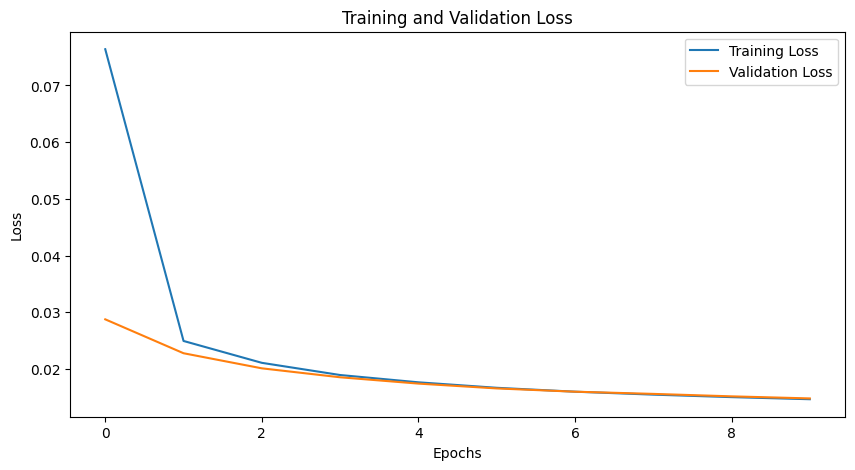

In [12]:
# Plot training and validation loss
pyplot.figure(figsize=(10, 5))
pyplot.plot(train_losses, label='Training Loss')
pyplot.plot(validation_losses, label='Validation Loss')
pyplot.xlabel('Epochs')
pyplot.ylabel('Loss')
pyplot.title('Training and Validation Loss')
pyplot.legend()
pyplot.show()

## Out-of-Distribution (OOD) Detection

In this task, perform out-of-distribution (OOD) detection via the reconstruction error from the trained network.
We will use the test set of EMNIST letters and FashionMNIST as OOD samples.
We will first reconstruct the images of the three test sets.
Then we will perform OOD detection by computing the sample-wise loss thresholding the reconstruction error.
Samples with an error below a certain threshold are considered in-distribution, while samples with an error above the threshold are considered OOD.

Forward the re-assigned loss as predictions into the function defined above to compute TPR and TNR. Compute the regular accuracy as well to make a comparison.

### Task 2.6: Reconstruction Result

This task is to visualize the reconstructed images from their originals.
For this purpose, load the first batch of each of the test sets. 
Forward the images through the trained auto-encoder network to extract their reconstructions.
Make a single plot with 2 rows and 10 columns. 
In the 1st row, plot the original samples and in the 2nd row plot the corresponding reconstructed samples. 

Then, for each dataset, compute the average reconstruction error of the entire dataset and print it.
Hint: you can reuse the `test()` function from task 2.5.

You should be able to see that the reconstruction error is much larger for the OOD samples (especially for far-OOD samples) than for the in-distribution samples.
This is a good sign that the auto-encoder network is able to detect OOD samples.

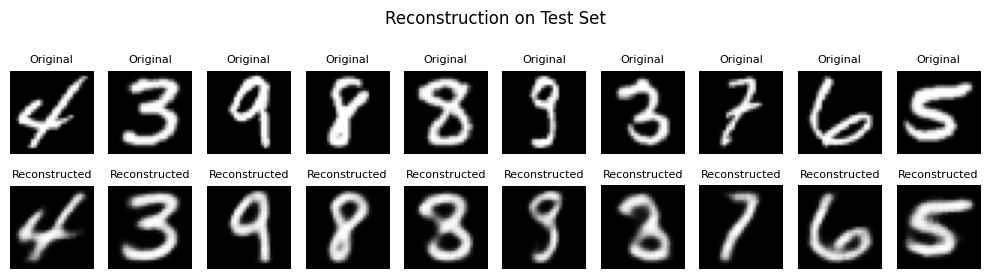

100%|██████████| 79/79 [00:00<00:00, 338.30it/s]


Average Test Reconstruction Error: 0.014824


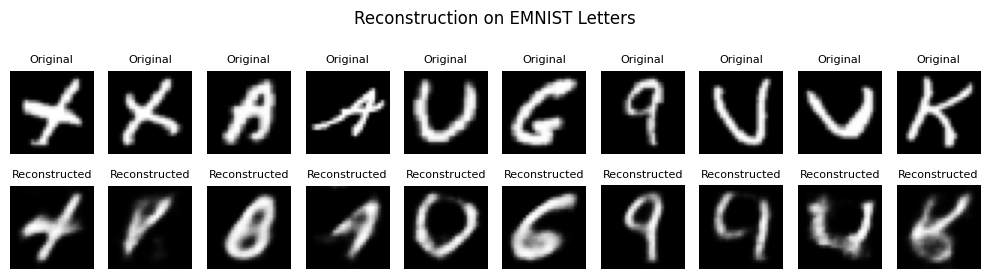

100%|██████████| 163/163 [00:00<00:00, 335.54it/s]


Average Open-set Test Reconstruction Error on EMNIST Letters: 0.038619


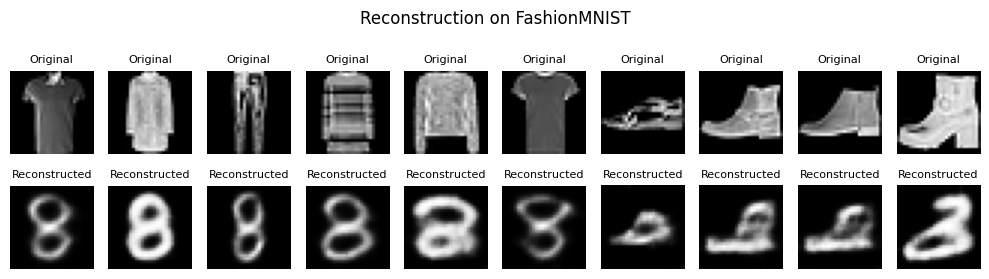

100%|██████████| 79/79 [00:00<00:00, 360.89it/s]

Average Open-set Test Reconstruction Error on Fashion MNIST: 0.073729


In [13]:
# Visualization of some reconstructed images
def visualize_reconstruction(data_loader, data_set_name, num_images=10):
    """Display a row of original images alongside their reconstructions.

    Args:
    data_loader: The data loader to sample images to be reconstructed
    data_set_name: The name of the dataset, for displaying purposes only
    num_images: The number of images to reconstruct and display
    """
    assert num_images <= batch_size, "num_images should be less than or equal to batch size"
    # put the model into evaluation mode
    model.eval()
    with torch.no_grad():
        # Get a batch of test images
        X, _ = next(iter(data_loader))
        X = X.to(device)

        # Generate reconstructions
        Y = model(X)

        # Move tensors to CPU
        X = X.cpu()
        Y = Y.cpu()

        # Plot original vs reconstructed images
        fig, axs = pyplot.subplots(2, num_images, figsize=(num_images, 3))
        fig.suptitle(f"Reconstruction on {data_set_name}")
        # flatten the 2D grid of axes so we can index it linearly
        axs = axs.flatten()

        for i in range(num_images):
            # Original images in the top row
            ax = axs[i]
            ax.imshow(X[i][0], cmap='gray')
            ax.set_title("Original", fontsize=8)
            ax.axis('off')

            # Reconstructed images in the bottom row
            ax = axs[i + num_images]
            ax.imshow(Y[i][0], cmap='gray')
            ax.set_title("Reconstructed", fontsize=8)
            ax.axis('off')

        pyplot.tight_layout()
        pyplot.show()

# visualize reconstructions and compute the average reconstruction error on the in-distribution test set
visualize_reconstruction(test_loader, "Test Set")
reconstruction_error_test = test(test_loader).mean()
print(f'Average Test Reconstruction Error: {reconstruction_error_test:.6f}')

# Visualize some open-set samples for EMNIST letters and FashionMNIST

# EMNIST letters
visualize_reconstruction(emnist_letters_loader, "EMNIST Letters")
# Evaluate reconstruction error on open-set samples
reconstruction_error_emnist = test(emnist_letters_loader).mean()
print(f'Average Open-set Test Reconstruction Error on EMNIST Letters: {reconstruction_error_emnist:.6f}')

# FashionMNIST
visualize_reconstruction(fashion_mnist_loader, "FashionMNIST")
# Evaluate reconstruction error on open-set samples
reconstruction_error_fashion = test(fashion_mnist_loader).mean()
print(f'Average Open-set Test Reconstruction Error on Fashion MNIST: {reconstruction_error_fashion:.6f}')


### Task 2.7: Visualizing the OOD Signal

We now exploit the inability of the AE network to reconstruct OOD samples, by using the reconstruction error as a signal for OOD detection and applying a threshold to the reconstruction error.
Determine a reasonable `ood_threshold` from the plot of this task (you need to run the plotting with value `0` first, and then you can decide for a good threshold) that can be used classify the samples as in-distribution or OOD.
Compute and plot the distribution of test errors on all three datasets as a histogram along with the threshold, in order to visualize the OOD detection performance.

100%|██████████| 79/79 [00:00<00:00, 359.55it/s]


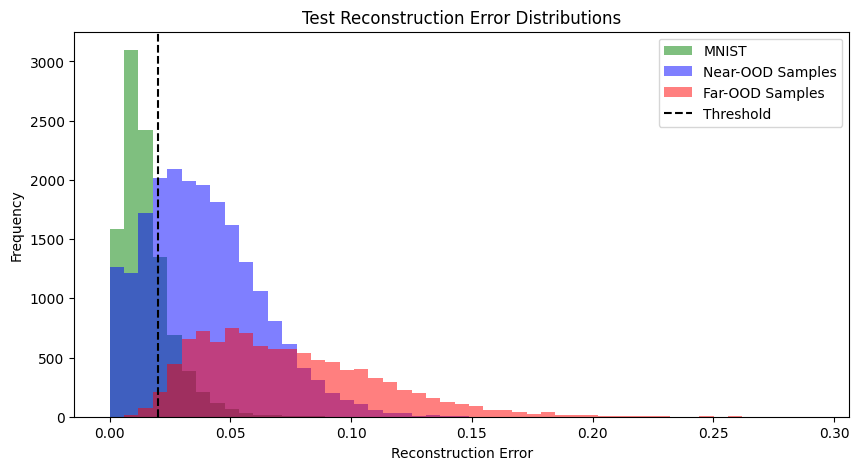

In [14]:
# Plot a histogram overlay of reconstruction errors for the three datasets, with a threshold line.

# define a reasonable threshold for distinguishing ID and OOD samples, using this plot
# make sure to set this threshold to a reasonable value before continuing to the next cell
ood_threshold = 0.02

# gather per-sample reconstruction errors for each dataset
test_errors = test(test_loader)
emnist_letters_errors = test(emnist_letters_loader)
fashion_mnist_errors = test(fashion_mnist_loader)

pyplot.figure(figsize=(10, 5))
# combine all errors to determine a common range for the histogram bins
all_errors = torch.cat([torch.as_tensor(test_errors), torch.as_tensor(emnist_letters_errors), torch.as_tensor(fashion_mnist_errors)])
bins = torch.linspace(0, all_errors.max(), 50)

# overlay the three histograms with partial transparency
pyplot.hist(test_errors, bins=bins, alpha=0.5, color='green', label='MNIST')
pyplot.hist(emnist_letters_errors, bins=bins, alpha=0.5, color='blue', label='Near-OOD Samples')
pyplot.hist(fashion_mnist_errors, bins=bins, alpha=0.5, color='red', label='Far-OOD Samples')

# mark the threshold as a vertical dashed line (not shown in the example plot)
if ood_threshold is not None:
    pyplot.axvline(ood_threshold, color='black', linestyle='--', label='Threshold')
pyplot.xlabel('Reconstruction Error')
pyplot.ylabel('Frequency')
pyplot.title('Test Reconstruction Error Distributions')
pyplot.legend()
pyplot.show()


### Task 2.8: True Positive/Negative Rate Calculation

Define a function that takes the predictions and truth values, as lists, and returns TPR and TNR.

You can use `sklearn.metrics.confusion_matrix` (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) to compute true positives, true negatives, false positives, and false negatives, or compute them by their definitions.


In [15]:
def compute_tpr_tnr(predictions, labels):
    """Compute the true positive rate and true negative rate from predictions and ground-truth labels.

    Args:
    predictions: The predicted classes (-1 or 1) in shape B
    labels: The ground-truth labels (-1 or 1) in shape B

    Returns:
    True Positive Rate
    True Negative Rate
    """
    from sklearn.metrics import confusion_matrix
    # Compute the confusion matrix, directly from the torch tensors
    tn, fp, fn, tp = confusion_matrix(labels.cpu().numpy(), predictions.cpu().numpy(), labels=[-1, 1]).ravel()
    # Compute TPR and TNR
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    return tpr, tnr


### Test 3: TPR & TNR Calculation Check

With the given labels and predictions, call the function defined in Task 2.8 and check the returned TPR and TNR are correct.

In [16]:
labels_ = torch.tensor([1, 1, 1, 1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1])
predictions_ = torch.tensor([1, -1, 1, 1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1])

# Compute TPR and TNR
tpr_, tnr_ = compute_tpr_tnr(predictions_, labels_)

assert(abs(tpr_ - 14/15) < 1e-8)
assert(abs(tnr_ - 0.8) < 1e-8)

### Task 2.9: Evaluating OOD Detection

Now we will perform OOD detection by computing the sample-wise loss
In order to evaluate the performance, we need to convert the labels into binary labels and assign binary predictions.
Assign 1 to samples with a reconstruction error smaller than your `ood_threshold`, and -1 otherwise.
We adjust the labels accordingly.
Then, compute the TPR and TNR for the three datasets.

In [17]:
# collect predictions and labels across all three datasets
predictions = []
labels = []
for dataloader in [test_loader, emnist_letters_loader, fashion_mnist_loader]:
    # run the evaluation pass to obtain per-sample losses
    losses = test(dataloader)

    # gather ground-truth labels for this dataset (in dataloader order)
    truth = torch.cat([t for _, t in dataloader])

    # Compute binary predictions and labels: 1 for in-distribution, -1 for out-of-distribution
    binary_prediction = torch.where(losses < ood_threshold, 1, -1)
    binary_labels = torch.where(truth == -1, -1, 1)

    predictions.append(binary_prediction)
    labels.append(binary_labels)

# concatenate the per-dataset tensors into a single tensor
predictions = torch.cat(predictions)
truth = torch.cat(labels)

# Compute TPR and TNR
tpr, tnr = compute_tpr_tnr(predictions, truth)
print(f'True Positive Rate (TPR): {tpr:.6f}')
print(f'True Negative Rate (TNR): {tnr:.6f}')


100%|██████████| 79/79 [00:00<00:00, 360.39it/s]


True Positive Rate (TPR): 0.770400
True Negative Rate (TNR): 0.835974


## Open-Set Recognition

So far we have ignored the class labels of the training data and only made the binary distinction between in and out-of-distribution samples.
In this task, we will use the class labels of the training data to perform open-set recognition, which also considers the class labels of the in-distribution samples.
We will show that we can solve the in-distribution classification task with the encoder network that was trained in an unsupervised fashion.

### Task 2.10: OSR via Class Distance

We will perform the in-distribution classification task by computing class centroids, i.e. the average deep feature representations of the training data for each class.
Then we will compute the Euclidean distance between the deep feature representation of the test sample and the class centroids.
The class with the smallest distance is assigned to the test sample.
Instead of using the reconstruction error as a signal of OODness, we will use the distance between the deep feature representation of the sample and the class centroids as signal of OODness and apply a threshold to the minimal distance of any test sample to all class centroids.

- Compute the class centroids for the training set. 
    - Store them in a torch tensor of shape ($O$, $K$), where $K$ is the deep feature dimension and $O$ is the number of known classes.
    - It is advised to compute a dictionary first with the class labels as keys and a list of all the deep feature representations as values, then compute the mean of each list and store it in the tensor.
- Compute the distances of each sample to each class center. Use the `torch.cdist` function to compute the Euclidean distances for an entire batch at once.
- Predict the classes for the test samples as follows:
    - If for a sample the minimum distance to any class centroid is larger than the `osr_threshold`, assign it the label `-1` (unknown).
    - Otherwise, assign it the label of the class centroid with the smallest distance.

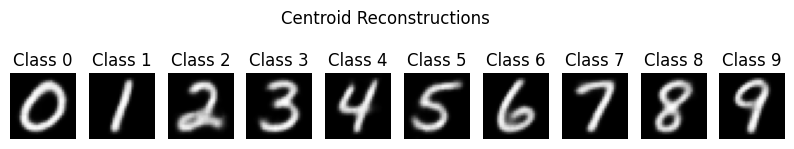

In [18]:
class OSRClassifier():
    """Open-set recognition classifier based on distances to class centroids in deep feature space."""
    def __init__(self, autoencoder):
        # keep references to the encoder and decoder of the trained auto-encoder
        self.encoder = autoencoder.encoder
        self.decoder = autoencoder.decoder

    def compute_centroids(self):
        """Compute and store the centroid of deep features for each class."""
        # put the encoder into evaluation mode
        self.encoder.eval()
        # mapping from class label to a collection of deep features
        class_features = {}
        with torch.no_grad():
            for x, t in train_loader:
                x = x.to(device)
                # encode the batch into deep features
                deep_features = self.encoder(x).cpu()
                for i, label in enumerate(t):
                    lab = label.item()
                    if lab not in class_features:
                        class_features[lab] = []
                    # append features for this label
                    class_features[lab].append(deep_features[i])

        # Initialize centroids in reasonable data structure (O classes x K features)
        num_classes = max(class_features.keys()) + 1
        K = next(iter(class_features.values()))[0].shape[0]
        self.centroids = torch.zeros(num_classes, K)
        # Compute the mean of the deep features for each class
        for label in class_features:
            self.centroids[label] = torch.stack(class_features[label]).mean(dim=0)

    def compute_distances(self, data_loader):
        """Compute the distances from each sample's deep feature to all stored centroids.

        Args:
        data_loader: The test set data loader to use

        Returns:
        distances: The distances of all samples to all class means, in shape NxO
        labels: The correct class label, in shape N
        """
        self.encoder.eval()
        distances = []
        labels = []
        centroids_dev = self.centroids.to(device)
        with torch.no_grad():
            for X, T in data_loader:
                X = X.to(device)
                # extract deep features from the autoencoder
                deep_features = self.encoder(X)

                # Compute distances to all centroids for each sample
                dist = torch.cdist(deep_features, centroids_dev)
                distances.append(dist.cpu())
                labels.append(T)

        # stack the per-batch results into single tensors
        distances = torch.cat(distances)
        labels = torch.cat(labels)

        return distances, labels

    def predict(self, data_loader, threshold):
        """Predict class labels, assigning -1 when the sample is considered out-of-distribution.

        Args:
        data_loader: The test set data loader to use
        threshold: The threshold to be used for unknown class

        Returns:
        predictions: The predicted class, including the unknown class -1, in shape N
        labels: The correct class label, in shape N
        """
        self.encoder.eval()
        # compute distances to the stored centroids
        distances, labels = self.compute_distances(data_loader)

        # Make predictions based on the threshold
        min_distances, min_indices = distances.min(dim=1)
        predictions = torch.where(min_distances > threshold, torch.full_like(min_indices, -1), min_indices)

        return predictions, labels

    def plot_centroid_reconstruction(self, num_images=10):
        """Decode each class centroid and display the resulting images."""
        # We have implemented this for you.
        self.encoder.eval()
        with torch.no_grad():

            # pass the centroids through the decoder to obtain images
            reconstruction = self.decoder(self.centroids.clone().to(device)).cpu()

            # Plot the centroids
            fig, axs = pyplot.subplots(1, num_images, figsize=(num_images, 2))
            fig.suptitle("Centroid Reconstructions")
            for i in range(num_images):
                axs[i].imshow(reconstruction[i][0], cmap='gray')
                axs[i].set_title(f"Class {i}")
                axs[i].axis('off')
            pyplot.show()

# Create OSR classifier for the autoencoder
osr_classifier = OSRClassifier(model)
# compute centroids for the training set
osr_classifier.compute_centroids()
# Plot reconstructed centroids
osr_classifier.plot_centroid_reconstruction(num_images=10)


### Task 2.11: Visualization of Distances to Class Centroids
Plot the distances of the test samples to the class centroids as a histogram.
Make sure to plot the distances for the three datasets in a single plot.
Assign `ood_threshold=None` in the first round to plot the distributions.
Then, set it to a reasonable value and call this plot again.

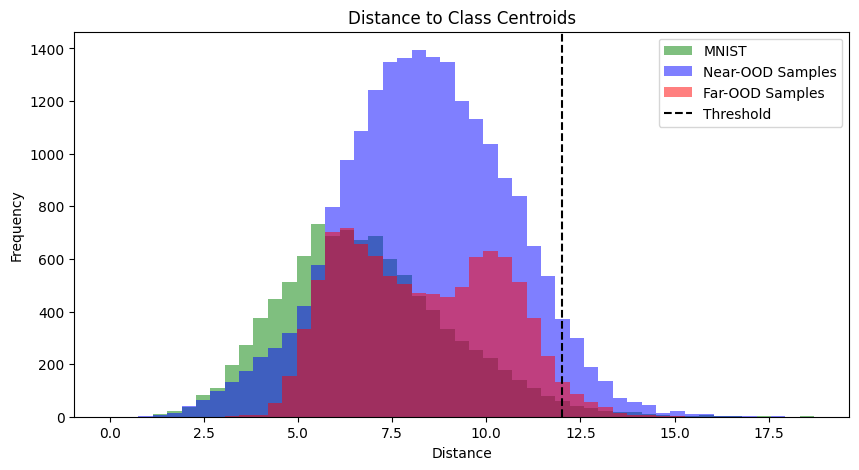

In [19]:
# Set this threshold to a reasonable value before going on with the next cell
osr_threshold = 12.0

# gather the distance tensors for each dataset
test_distances, _ = osr_classifier.compute_distances(test_loader)
emnist_letters_distances, _ = osr_classifier.compute_distances(emnist_letters_loader)
fashion_mnist_distances, _ = osr_classifier.compute_distances(fashion_mnist_loader)

# compute min distances per sample over all classes
min_test_distances = test_distances.min(dim=1).values
min_emnist_letters_distances = emnist_letters_distances.min(dim=1).values
min_fashion_mnist_distances = fashion_mnist_distances.min(dim=1).values

pyplot.figure(figsize=(10, 5))
# concatenate distances to determine a common histogram range
all_distances = torch.cat([min_test_distances, min_emnist_letters_distances, min_fashion_mnist_distances])
bins = torch.linspace(0, all_distances.max(), 50)
# overlay histograms with partial transparency for comparison
pyplot.hist(min_test_distances, bins=bins, alpha=0.5, color='green', label='MNIST')
pyplot.hist(min_emnist_letters_distances, bins=bins, alpha=0.5, color='blue', label='Near-OOD Samples')
pyplot.hist(min_fashion_mnist_distances, bins=bins, alpha=0.5, color='red', label='Far-OOD Samples')
# draw the threshold as a vertical dashed line (not shown in the example plot)
if osr_threshold is not None:
    pyplot.axvline(osr_threshold, color='black', linestyle='--', label='Threshold')
pyplot.xlabel('Distance')
pyplot.ylabel('Frequency')
pyplot.title('Distance to Class Centroids')
pyplot.legend()
pyplot.show()


### Task 2.12: OSR Evaluation

In this task, we will evaluate the performance of the open-set recognition system on the test sets.
We will use the same evaluation metrics as in the OOD detection task, i.e. TPR and TNR.
In addition, we compute the closed-set accuracy on the known classes and plot the corresponding confusion matrix.
Make sure to only compute the accuracy and confusion matrix on the known classes, i.e. the samples with labels 0-9.

Note: There exist evaluation metrics such as the OSCR (Open Set Classification Rate) that are more suitable for open-set recognition tasks, but we will use the TPR and TNR metrics for simplicity here.

True Positive Rate (TPR): 0.979900
True Negative Rate (TNR): 0.043539


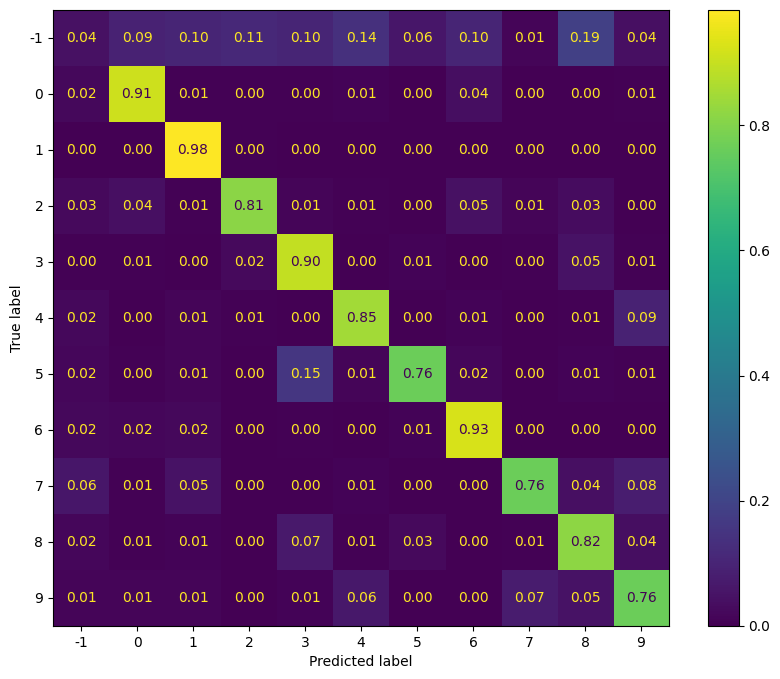

In [20]:
# compute TPR and TNR on all datasets
predictions = []
labels = []
# iterate over each dataset and accumulate the predictions and labels
for dataloader in [test_loader, emnist_letters_loader, fashion_mnist_loader]:
    pred, label = osr_classifier.predict(dataloader, osr_threshold)
    predictions.append(pred)
    labels.append(label)

# move the concatenated tensors to CPU for use with sklearn/matplotlib
predictions = torch.cat(predictions).cpu()
labels = torch.cat(labels).cpu()

# Compute binary predictions and labels: 1 for in-distribution, -1 for out-of-distribution
binary_labels = torch.where(labels == -1, -1, 1)
binary_predictions = torch.where(predictions == -1, -1, 1)

# Compute TPR and TNR
tpr, tnr = compute_tpr_tnr(binary_predictions, binary_labels)
print(f'True Positive Rate (TPR): {tpr:.6f}')
print(f'True Negative Rate (TNR): {tnr:.6f}')

# plot confusion matrix, including unknown class
figure = pyplot.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    labels.numpy(),
    predictions.numpy(),
    labels=list(range(-1,10)),
    normalize='true',
    ax=figure.gca(),
    values_format="1.2f"
)
pyplot.savefig("Assignment04_Task2.12_confusion_matrix.pdf", bbox_inches="tight")
pyplot.show()
